# Sesión 1 · Introducción al Reinforcement Learning desde cero

**Máster en IA · Reinforcement Learning**

---

## Qué vamos a hacer en este notebook

En esta primera sesión no vamos a intentar "ver todos los algoritmos de RL".  
Vamos a hacer algo más importante: **entender bien el problema** que resuelve Reinforcement Learning.

La idea es que, al acabar este notebook, el alumno tenga muy claros estos conceptos:

- qué es RL y en qué se diferencia de aprendizaje supervisado y no supervisado,
- qué significan **agente**, **entorno**, **estado**, **acción** y **recompensa**,
- qué es un **episodio**,
- qué es el **retorno**,
- qué es una **política**,
- por qué existe el conflicto entre **exploración** y **explotación**,
- qué significa, de forma intuitiva, que un problema tenga estructura de **MDP**,
- por qué una recompensa inmediata puede entrar en conflicto con el objetivo a largo plazo.



RECURSOS:
- La biblia del RL: http://www.incompleteideas.net/book/ebook/
- Uno de los mejores cursos: https://huggingface.co/learn/deep-rl-course/unit0/introduction
- Un blog muy chulo, jic: https://blog.adrianistan.eu/reinforcement-learning-aprendizaje-refuerzo-que-es-parte-1/

# 1. ¿Qué problema resuelve Reinforcement Learning?

En Reinforcement Learning, un agente no recibe una tabla con respuestas correctas del tipo:

> "para esta entrada, la salida correcta es esta"

Tampoco se limita a agrupar datos o a encontrar estructura escondida sin un objetivo de acción.

En cambio, en RL ocurre esto:

1. el agente **observa** en qué situación está,
2. **elige una acción**,
3. el entorno responde,
4. recibe una **recompensa**,
5. y a partir de la experiencia intenta aprender a **tomar mejores decisiones** en el futuro.

La clave aquí es la palabra **decisiones**.

RL trata sobre **aprender a actuar**.

## Diferencia muy intuitiva con otros paradigmas

### Aprendizaje supervisado
En supervisado tenemos pares de entrada-salida:

- imagen -> gato / perro
- correo -> spam / no spam
- variables de vivienda -> precio

El modelo aprende a **predecir**.

### Aprendizaje no supervisado
En no supervisado normalmente no hay etiqueta objetivo explícita:

- clustering,
- reducción de dimensionalidad,
- detección de estructura latente.

El modelo aprende a **describir o estructurar** los datos.

### Reinforcement Learning
En RL el sistema aprende a **actuar secuencialmente** para maximizar recompensa acumulada.

No suele haber una "respuesta correcta" para cada paso aislado.
Lo importante es si la **secuencia completa de decisiones** acaba siendo buena.

In [1]:
paradigmas = {
    "Supervisado": "Aprender a predecir una salida a partir de ejemplos etiquetados",
    "No supervisado": "Aprender estructura o patrones sin etiquetas objetivo",
    "Reinforcement Learning": "Aprender a tomar decisiones secuenciales maximizando recompensa",
}

for nombre, descripcion in paradigmas.items():
    print(f"{nombre}:")
    print(f"  - {descripcion}\n")

Supervisado:
  - Aprender a predecir una salida a partir de ejemplos etiquetados

No supervisado:
  - Aprender estructura o patrones sin etiquetas objetivo

Reinforcement Learning:
  - Aprender a tomar decisiones secuenciales maximizando recompensa



## Ejemplo conceptual

Imagina un robot en un laberinto:

- en supervisado podrías darle muchas imágenes del laberinto con la **acción correcta ya etiquetada**,
- en RL no le das esa respuesta correcta paso a paso,
- simplemente le dejas actuar y le dices algo como:
  - +10 si llega a la meta,
  - -5 si cae en una trampa,
  - -0.1 por cada paso para que no dé vueltas innecesarias.

Entonces el robot tiene que aprender, por experiencia, qué decisiones lo llevan a mejores resultados.

Eso es mucho más parecido a **probar, equivocarse, corregirse y mejorar**.

# 2. Los ingredientes básicos de RL

Vamos a fijar vocabulario desde el primer momento.

## Agente
Es quien toma decisiones.

## Entorno
Es "el mundo" con el que interactúa el agente.

## Estado
Es la situación actual en la que se encuentra el agente.

## Acción
Es lo que el agente puede hacer.

## Recompensa
Es la señal numérica que indica si lo que ha pasado ha sido bueno o malo.

En nuestro GridWorld:

- el **agente** será un punto que se mueve,
- el **entorno** será una rejilla,
- el **estado** será la posición del agente en la rejilla,
- las **acciones** serán movernos arriba, abajo, izquierda o derecha,
- la **recompensa** dependerá de dónde acabemos.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

np.set_printoptions(suppress=True, precision=3)

In [3]:
ACTIONS = {
    0: "arriba",
    1: "derecha",
    2: "abajo",
    3: "izquierda",
}

for k, v in ACTIONS.items():
    print(f"{k} -> {v}")

0 -> arriba
1 -> derecha
2 -> abajo
3 -> izquierda


Obsérvese que las acciones están codificadas con enteros.

Esto es muy habitual en RL:

- internamente el agente trabaja con representaciones simples,
- pero nosotros mostramos un nombre legible para interpretar mejor qué está pasando.

# 3. Nuestro primer entorno: un GridWorld muy simple

Vamos a diseñar una rejilla con:

- una casilla inicial,
- una meta,
- una trampa,
- y un coste pequeño por cada paso.

¿Por qué poner coste por paso?

Porque si no lo hiciéramos, al agente podría darle igual dar rodeos eternamente mientras no caiga en algo malo.
El coste por paso hace que "llegar antes" sea mejor que "llegar tarde".

Esto es muy importante:  
**el reward define muchísimo el comportamiento**.

- En RL el entorno suele implementar una función llamada step().
- Esta función representa lo que ocurre cuando el agente actúa.
- Siempre devuelve tres cosas:
    -      nuevo estado, 
    -      recompensa y 
    -      si el episodio ha terminado.

In [4]:
# Usamos dataclass simplemente para crear una estructura ligera que nos permita
# devolver varios valores a la vez cuando el agente realiza una acción.
# Es equivalente a devolver una tupla, pero mucho más legible.

@dataclass
class StepResult:
    next_state: tuple     # estado al que hemos llegado después de actuar
    reward: float         # recompensa obtenida en este paso
    terminated: bool      # indica si el episodio ha terminado


class SimpleGridWorld:
    """
    Este es nuestro entorno de RL.

    Representa una cuadrícula (grid) donde un agente se mueve.

    La cuadrícula contiene:
    - una casilla inicial (start)
    - una meta (goal)
    - una trampa (trap)
    - el resto de casillas normales

    El agente puede moverse en cuatro direcciones:
    arriba, derecha, abajo, izquierda.
    """

    def __init__(self, rows=4, cols=4, start=(0, 0), goal=(3, 3), trap=(1, 3), step_cost=-0.1):
        """
        Constructor del entorno.

        rows, cols -> tamaño del grid
        start      -> posición inicial del agente
        goal       -> posición de la meta
        trap       -> posición de la trampa
        step_cost  -> penalización por cada paso
        """

        # dimensiones del grid
        self.rows = rows
        self.cols = cols

        # posiciones especiales
        self.start = start
        self.goal = goal
        self.trap = trap

        # penalización por paso
        # sirve para que el agente no dé vueltas infinitas
        self.step_cost = step_cost

        # estado actual del agente
        self.state = start


    def reset(self):
        """
        Reinicia el entorno.

        Esto equivale a empezar un nuevo episodio.
        El agente vuelve a la posición inicial.
        """

        self.state = self.start
        return self.state


    def state_to_id(self, state):
        """
        Convierte una posición (fila, columna) en un índice entero.

        Ejemplo en un grid 4x4:

        (0,0) -> 0
        (0,1) -> 1
        (0,2) -> 2
        (0,3) -> 3
        (1,0) -> 4
        ...

        Esto es útil porque muchos algoritmos de RL trabajan con
        índices enteros en lugar de tuplas.
        """

        return state[0] * self.cols + state[1]


    def id_to_state(self, idx):
        """
        Hace la operación inversa:

        índice entero -> coordenadas (fila, columna)
        """

        return (idx // self.cols, idx % self.cols)


    def valid_state(self, r, c):
        """
        Comprueba si una posición está dentro del grid.

        Si el agente intenta salir del tablero,
        lo consideraremos una acción inválida y lo dejaremos
        en la misma posición.
        """

        return 0 <= r < self.rows and 0 <= c < self.cols


    def step(self, action):
        """
        Esta es la función más importante del entorno.

        Representa lo que ocurre cuando el agente realiza una acción.

        Entrada:
            action -> entero que representa la acción elegida

        Salida:
            StepResult con:
                - nuevo estado
                - recompensa obtenida
                - si el episodio ha terminado
        """

        # estado actual del agente
        r, c = self.state

        # calculamos la nueva posición en función de la acción

        if action == 0:        # arriba
            nr, nc = r - 1, c

        elif action == 1:      # derecha
            nr, nc = r, c + 1

        elif action == 2:      # abajo
            nr, nc = r + 1, c

        elif action == 3:      # izquierda
            nr, nc = r, c - 1

        else:
            raise ValueError("Acción no válida")


        # si la nueva posición se sale del grid
        # el agente no se mueve
        if not self.valid_state(nr, nc):
            nr, nc = r, c


        # actualizamos el estado del agente
        self.state = (nr, nc)


        # ahora calculamos la recompensa y si el episodio termina

        if self.state == self.goal:
            # el agente ha llegado a la meta
            return StepResult(self.state, 10.0, True)

        elif self.state == self.trap:
            # el agente ha caído en la trampa
            return StepResult(self.state, -5.0, True)

        else:
            # casilla normal
            return StepResult(self.state, self.step_cost, False)


    def render_text(self):
        """
        Imprime el grid en texto para visualizar el entorno.

        Símbolos:
            S -> start
            G -> goal
            X -> trap
            A -> agente
            . -> casilla normal
        """

        # creamos una matriz llena de puntos
        grid = [["." for _ in range(self.cols)] for _ in range(self.rows)]

        # posiciones especiales
        sr, sc = self.start
        gr, gc = self.goal
        tr, tc = self.trap

        # posición actual del agente
        ar, ac = self.state

        # colocamos las marcas en el grid
        grid[sr][sc] = "S"
        grid[gr][gc] = "G"
        grid[tr][tc] = "X"

        # el agente solo se dibuja si no está en una casilla especial
        if (ar, ac) not in [self.start, self.goal, self.trap]:
            grid[ar][ac] = "A"

        # imprimimos el grid fila por fila
        for row in grid:
            print(" ".join(row))


    def reward_map(self):
        """
        Devuelve una matriz con las recompensas de cada casilla.

        Esto es útil para visualizar el entorno y entender
        qué zonas son buenas o malas.
        """

        # inicialmente todas las casillas tienen el coste por paso
        rewards = np.full((self.rows, self.cols), self.step_cost)

        # sobrescribimos meta y trampa
        rewards[self.goal] = 10.0
        rewards[self.trap] = -5.0

        return rewards

In [5]:
env = SimpleGridWorld()
estado_inicial = env.reset()
print("Estado inicial:", estado_inicial)
env.render_text()

Estado inicial: (0, 0)
S . . .
. . . X
. . . .
. . . G


In [6]:
env.reward_map()

array([[-0.1, -0.1, -0.1, -0.1],
       [-0.1, -0.1, -0.1, -5. ],
       [-0.1, -0.1, -0.1, -0.1],
       [-0.1, -0.1, -0.1, 10. ]])

Aquí se ve algo muy importante:

- casi todas las casillas tienen recompensa `-0.1`,
- la meta tiene `+10`,
- la trampa tiene `-5`.

Eso significa que el agente **no optimiza una sola acción**.
Optimiza la **suma** de lo que va recibiendo.

# 4. Estado y transición: qué pasa cuando el agente actúa

La idea aquí no es todavía "entrenar".  
La idea es entender la mecánica básica:

- el agente está en un estado,
- elige una acción,
- el entorno responde con:
  - nuevo estado,
  - recompensa,
  - indicador de fin de episodio.

In [7]:
env = SimpleGridWorld()
state = env.reset()
print("Estado antes de actuar:", state)

resultado = env.step(1)  # derecha
print("\nAcción elegida: derecha")
print("Nuevo estado:", resultado.next_state)
print("Recompensa:", resultado.reward)
print("¿Terminado?:", resultado.terminated)

print("\nRender tras mover:")
env.render_text()

Estado antes de actuar: (0, 0)

Acción elegida: derecha
Nuevo estado: (0, 1)
Recompensa: -0.1
¿Terminado?: False

Render tras mover:
S A . .
. . . X
. . . .
. . . G


In [8]:
env = SimpleGridWorld()
env.reset()

secuencia = [1, 1, 1]
for i, action in enumerate(secuencia, start=1):
    resultado = env.step(action)
    print(f"Paso {i} | acción={ACTIONS[action]:>9} | estado={resultado.next_state} | recompensa={resultado.reward:>4} | terminado={resultado.terminated}")
    if resultado.terminated:
        break

Paso 1 | acción=  derecha | estado=(0, 1) | recompensa=-0.1 | terminado=False
Paso 2 | acción=  derecha | estado=(0, 2) | recompensa=-0.1 | terminado=False
Paso 3 | acción=  derecha | estado=(0, 3) | recompensa=-0.1 | terminado=False


In [9]:
env.render_text()

S . . A
. . . X
. . . .
. . . G


En este caso el agente ha ido hacia la derecha hasta caer en la trampa.

Fíjate en la diferencia entre:

- **acciones individuales**,
- y **consecuencia de la secuencia completa**.

# 5. Episodio, horizonte y retorno

## Episodio
Un episodio es una ejecución completa del agente desde un inicio hasta un final.

En nuestro GridWorld, un episodio termina cuando:

- el agente llega a la meta, o
- cae en la trampa.

## Retorno
Es la suma acumulada de recompensas a lo largo del episodio.

Si las recompensas de un episodio son:

`[-0.1, -0.1, -0.1, 10]`

entonces el retorno total es `9.7`.

In [10]:
recompensas = [-0.1, -0.1, -0.1, 10]
retorno = sum(recompensas)

print("Recompensas del episodio:", recompensas)
print("Retorno total:", retorno)

Recompensas del episodio: [-0.1, -0.1, -0.1, 10]
Retorno total: 9.7


En RL, muchas veces no nos interesa maximizar la recompensa del siguiente paso solamente.

Nos interesa maximizar el **retorno acumulado**.

Por eso un agente puede aceptar varios pasos con coste negativo pequeño si eso le lleva a una meta final mucho mejor.

https://www.youtube.com/watch?v=tlOIHko8ySg

## Una nota sobre retorno descontado

En muchos cursos se introduce pronto el factor de descuento `gamma`.

La idea intuitiva es:

- recompensas futuras siguen importando,
- pero quizá importan un poco menos que las inmediatas.

Formalmente, el retorno descontado sería:

$$
G_t = r_{t+1} + \gamma r_{t+2} + \gamma^2 r_{t+3} + \dots
$$

In [11]:
recompensas = [-0.1, -0.1, -0.1, 10]
gamma = 0.9

retorno_desc = 0
for i, r in enumerate(recompensas):
    retorno_desc += (gamma ** i) * r

print("Recompensas:", recompensas)
print("Gamma:", gamma)
print("Retorno sin descuento:", sum(recompensas))
print("Retorno descontado:", round(retorno_desc, 4))

Recompensas: [-0.1, -0.1, -0.1, 10]
Gamma: 0.9
Retorno sin descuento: 9.7
Retorno descontado: 7.019


# 6. Política: cómo decide el agente

Una **política** es una regla de comportamiento.

Dicho de forma muy simple:

> una política dice qué acción elegir en cada estado.

Una política puede ser:

- aleatoria,
- fija y hecha a mano,
- aprendida a partir de experiencia.

## Políticas: diferentes formas de decidir qué hacer

Una **política (policy)** es simplemente una regla que le dice al agente **qué acción elegir cuando se encuentra en un estado**.

Formalmente podemos escribirlo como:

π(s) → a

Es decir:

estado → acción

En este ejemplo vamos a comparar tres tipos de políticas:

1. **Política aleatoria**  
   El agente elige cualquier acción al azar. No hay estrategia.

2. **Política artesanal simple**  
   El agente intenta avanzar hacia la derecha y, cuando no puede más, baja.

3. **Política artesanal algo más segura**  
   El agente baja primero y luego avanza hacia la derecha, evitando la trampa en nuestro entorno.

Estas políticas no "aprenden".  
Simplemente **codifican una regla fija de comportamiento**.

Esto nos permite comparar distintos comportamientos antes de introducir algoritmos que aprendan la política automáticamente.

In [14]:
# -------------------------------
# POLÍTICA 1: política aleatoria
# -------------------------------

def random_policy(state, rng=None):
    """
    Esta política ignora completamente el estado.

    El agente simplemente elige una acción al azar
    entre las 4 acciones posibles:
        0 -> arriba
        1 -> derecha
        2 -> abajo
        3 -> izquierda

    Esto representa un agente que no tiene ninguna
    estrategia ni conocimiento del entorno.
    """

    # Si no nos pasan un generador de números aleatorios,
    # creamos uno nuevo.
    # Usamos numpy.random.default_rng porque es el generador moderno
    # recomendado por numpy.
    rng = np.random.default_rng() if rng is None else rng

    # Elegimos un entero aleatorio entre 0 y 3 (incluido)
    return rng.integers(0, 4)



# ---------------------------------------------------
# POLÍTICA 2: avanzar a la derecha y luego hacia abajo
# ---------------------------------------------------

def greedy_right_down_policy(state):
    """
    Esta es una política hecha "a mano".

    Estrategia:
    - mientras no estemos en la última columna -> ir a la derecha
    - cuando lleguemos a la última columna -> bajar

    No tiene en cuenta trampas ni recompensas.
    Simplemente sigue una regla fija.
    """

    # El estado es una tupla (fila, columna)
    r, c = state

    # Si todavía no estamos en la última columna
    if c < 3:
        # acción 1 = derecha
        return 1

    # si ya estamos en la última columna, bajamos
    # acción 2 = abajo
    return 2



# ---------------------------------------------------
# POLÍTICA 3: bajar primero y luego avanzar a la derecha
# ---------------------------------------------------

def safer_handcrafted_policy(state):
    """
    Otra política artesanal.

    Estrategia:
    - bajar primero hasta la última fila
    - después avanzar hacia la derecha

    En nuestro entorno concreto esta política evita la trampa,
    porque la trampa está situada en la parte superior derecha.
    """

    r, c = state

    # mientras no estemos en la última fila
    if r < 3:
        # acción 2 = abajo
        return 2

    # cuando ya estemos en la última fila
    # avanzamos hacia la derecha
    return 1



# ---------------------------------------------------
# PROBAMOS LAS POLÍTICAS EN VARIOS ESTADOS
# ---------------------------------------------------

# Lista de estados que vamos a usar como ejemplo
# Cada estado es (fila, columna)
estados_de_prueba = [
    (0, 0),
    (0, 2),
    (2, 0),
    (3, 1)
]

# Creamos un generador aleatorio con semilla fija
# Esto hace que los resultados sean reproducibles
rng = np.random.default_rng(42)


# Para cada estado vamos a ver qué acción propone cada política
for s in estados_de_prueba:

    print(f"Estado {s}")

    # política aleatoria
    print("  random_policy ->", ACTIONS[random_policy(s, rng)])

    # política artesanal 1
    print("  greedy_right_down_policy ->", ACTIONS[greedy_right_down_policy(s)])

    # política artesanal 2
    print("  safer_handcrafted_policy ->", ACTIONS[safer_handcrafted_policy(s)])

    print()

Estado (0, 0)
  random_policy -> arriba
  greedy_right_down_policy -> derecha
  safer_handcrafted_policy -> abajo

Estado (0, 2)
  random_policy -> izquierda
  greedy_right_down_policy -> derecha
  safer_handcrafted_policy -> abajo

Estado (2, 0)
  random_policy -> abajo
  greedy_right_down_policy -> derecha
  safer_handcrafted_policy -> abajo

Estado (3, 1)
  random_policy -> derecha
  greedy_right_down_policy -> derecha
  safer_handcrafted_policy -> derecha



# 7. Ejecutar episodios completos

Vamos a construir una función que permita:

- reiniciar el entorno,
- aplicar una política paso a paso,
- guardar estados, acciones y recompensas,
- devolver todo el historial del episodio.

In [15]:
def run_episode(env, policy_fn, max_steps=30, seed=None, verbose=False):
    rng = np.random.default_rng(seed)
    state = env.reset()

    states = [state]
    actions = []
    rewards = []

    for step in range(max_steps):
        action = policy_fn(state) if policy_fn != random_policy else policy_fn(state, rng=rng)
        result = env.step(action)

        actions.append(action)
        rewards.append(result.reward)
        states.append(result.next_state)

        if verbose:
            print(f"Paso {step+1:02d} | estado={state} | acción={ACTIONS[action]:>9} | nuevo_estado={result.next_state} | recompensa={result.reward:>4} | terminado={result.terminated}")

        state = result.next_state

        if result.terminated:
            break

    return {
        "states": states,
        "actions": actions,
        "rewards": rewards,
        "return": sum(rewards),
        "terminated": len(rewards) > 0 and (states[-1] == env.goal or states[-1] == env.trap),
    }

In [19]:
# greedy_right_down_policy, random_policy, safer_handcrafted_policy


env = SimpleGridWorld()
env.render_text()

S . . .
. . . X
. . . .
. . . G


In [ ]:

episodio = run_episode(env, greedy_right_down_policy, verbose=True)

print("\nResumen:")
print("Estados visitados:", episodio["states"])
print("Acciones:", [ACTIONS[a] for a in episodio["actions"]])
print("Recompensas:", episodio["rewards"])
print("Retorno total:", episodio["return"])

# 8. Comparando políticas: aleatoria vs artesanal

Vamos a comparar tres comportamientos:

1. una política aleatoria,
2. una política artesanal algo torpe,
3. una política artesanal más segura.

In [20]:
env = SimpleGridWorld()

for nombre, politica in [
    ("Aleatoria", random_policy),
    ("Artesanal derecha-luego-abajo", greedy_right_down_policy),
    ("Artesanal segura", safer_handcrafted_policy),
]:
    episodio = run_episode(env, politica, seed=7, verbose=False)
    print(f"{nombre}")
    print("  Acciones:", [ACTIONS[a] for a in episodio["actions"]])
    print("  Recompensas:", episodio["rewards"])
    print("  Retorno:", episodio["return"])
    print("  Estado final:", episodio["states"][-1])
    print()

Aleatoria
  Acciones: ['izquierda', 'abajo', 'abajo', 'izquierda', 'abajo', 'izquierda', 'izquierda', 'arriba', 'arriba', 'derecha', 'derecha', 'izquierda', 'izquierda', 'arriba', 'derecha', 'izquierda', 'arriba', 'izquierda', 'arriba', 'derecha', 'izquierda', 'derecha', 'derecha', 'derecha', 'abajo']
  Recompensas: [-0.1, -0.1, -0.1, -0.1, -0.1, -0.1, -0.1, -0.1, -0.1, -0.1, -0.1, -0.1, -0.1, -0.1, -0.1, -0.1, -0.1, -0.1, -0.1, -0.1, -0.1, -0.1, -0.1, -0.1, -5.0]
  Retorno: -7.4
  Estado final: (1, 3)

Artesanal derecha-luego-abajo
  Acciones: ['derecha', 'derecha', 'derecha', 'abajo']
  Recompensas: [-0.1, -0.1, -0.1, -5.0]
  Retorno: -5.3
  Estado final: (1, 3)

Artesanal segura
  Acciones: ['abajo', 'abajo', 'abajo', 'derecha', 'derecha', 'derecha']
  Recompensas: [-0.1, -0.1, -0.1, -0.1, -0.1, 10.0]
  Retorno: 9.5
  Estado final: (3, 3)



# 9. Evaluar una política no es mirar un solo episodio

Un solo episodio puede engañarnos, especialmente si la política tiene azar.

Para evaluar una política necesitamos ejecutar muchos episodios y observar estadísticas como:

- retorno medio,
- porcentaje de éxito,
- longitud media del episodio.

In [22]:
def evaluate_policy(env_class, policy_fn, n_episodes=200, seed=0):
    returns = []
    successes = 0
    lengths = []

    for i in range(n_episodes):
        env = env_class()
        episode = run_episode(env, policy_fn, seed=seed + i)
        returns.append(episode["return"])
        lengths.append(len(episode["actions"]))
        if episode["states"][-1] == env.goal:
            successes += 1

    return {
        "mean_return": np.mean(returns),
        "std_return": np.std(returns),
        "success_rate": successes / n_episodes,
        "mean_length": np.mean(lengths),
        "returns": np.array(returns),
        "lengths": np.array(lengths),
    }

In [23]:
stats_random = evaluate_policy(SimpleGridWorld, random_policy, n_episodes=500, seed=123)
stats_greedy = evaluate_policy(SimpleGridWorld, greedy_right_down_policy, n_episodes=500, seed=123)
stats_safe = evaluate_policy(SimpleGridWorld, safer_handcrafted_policy, n_episodes=500, seed=123)

for nombre, stats in [
    ("Aleatoria", stats_random),
    ("Artesanal derecha-luego-abajo", stats_greedy),
    ("Artesanal segura", stats_safe),
]:
    print(nombre)
    print(f"  Retorno medio:      {stats['mean_return']:.3f}")
    print(f"  Desv. típica:       {stats['std_return']:.3f}")
    print(f"  Tasa de éxito:      {stats['success_rate']:.3f}")
    print(f"  Longitud media:     {stats['mean_length']:.3f}")
    print()

Aleatoria
  Retorno medio:      -2.793
  Desv. típica:       5.092
  Tasa de éxito:      0.156
  Longitud media:     21.438

Artesanal derecha-luego-abajo
  Retorno medio:      -5.300
  Desv. típica:       0.000
  Tasa de éxito:      0.000
  Longitud media:     4.000

Artesanal segura
  Retorno medio:      9.500
  Desv. típica:       0.000
  Tasa de éxito:      1.000
  Longitud media:     6.000



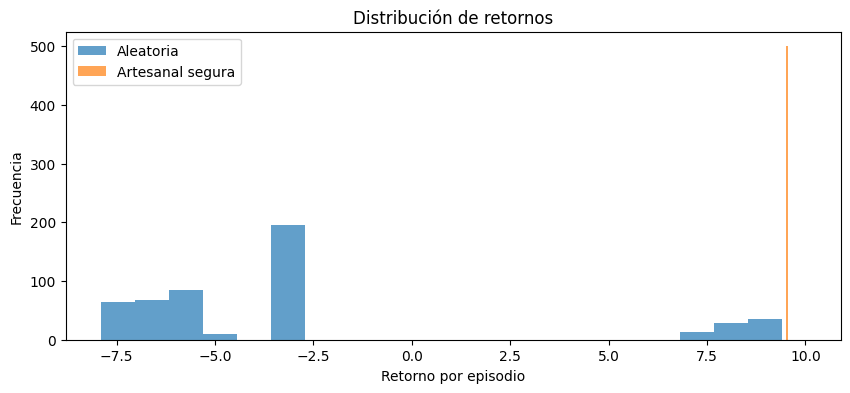

In [24]:
plt.figure(figsize=(10, 4))
plt.hist(stats_random["returns"], bins=20, alpha=0.7, label="Aleatoria")
plt.hist(stats_safe["returns"], bins=20, alpha=0.7, label="Artesanal segura")
plt.xlabel("Retorno por episodio")
plt.ylabel("Frecuencia")
plt.title("Distribución de retornos")
plt.legend()
plt.show()

## Visualización paso a paso de una política

Hasta ahora hemos comparado políticas mirando métricas como el retorno medio o la tasa de éxito.  
Pero en Reinforcement Learning también es muy útil **ver cómo se comporta el agente**.

En la siguiente celda vamos a animar un episodio completo:

- se reinicia el entorno,
- se aplica una política elegida,
- en cada paso se renderiza el grid,
- y se muestra cómo va cambiando la posición del agente.

Esto ayuda mucho a entender que una política no es una “nota final”, sino una **secuencia de decisiones**.

In [25]:
import time
from IPython.display import clear_output

def animate_episode(env, policy_fn, max_steps=30, delay=0.8, seed=None):
    """
    Ejecuta un episodio paso a paso y renderiza el grid en cada frame.

    Parámetros:
    - env: entorno ya creado
    - policy_fn: función que implementa la política
    - max_steps: número máximo de pasos del episodio
    - delay: pausa entre frames (en segundos)
    - seed: semilla para reproducibilidad, útil sobre todo con la política aleatoria
    """

    rng = np.random.default_rng(seed)

    # Reiniciamos el entorno al estado inicial
    state = env.reset()

    # Llevamos la cuenta del retorno acumulado
    total_reward = 0

    # Mostramos el frame inicial
    clear_output(wait=True)
    print("Frame inicial")
    print(f"Estado actual: {state}")
    print(f"Retorno acumulado: {total_reward:.2f}\n")
    env.render_text()
    time.sleep(delay)

    for step in range(1, max_steps + 1):

        # Caso especial: la política aleatoria necesita el generador rng
        if policy_fn == random_policy:
            action = policy_fn(state, rng=rng)
        else:
            action = policy_fn(state)

        # Aplicamos la acción en el entorno
        result = env.step(action)

        # Actualizamos retorno y estado
        total_reward += result.reward
        state = result.next_state

        # Limpiamos la salida anterior y mostramos el nuevo frame
        clear_output(wait=True)
        print(f"Paso {step}")
        print(f"Acción elegida: {ACTIONS[action]}")
        print(f"Nuevo estado: {state}")
        print(f"Recompensa del paso: {result.reward:.2f}")
        print(f"Retorno acumulado: {total_reward:.2f}")
        print(f"¿Episodio terminado?: {result.terminated}\n")
        env.render_text()

        time.sleep(delay)

        # Si el episodio termina, mostramos mensaje final y salimos
        if result.terminated:
            print("\nFin del episodio.")
            if state == env.goal:
                print("El agente ha llegado a la meta.")
            elif state == env.trap:
                print("El agente ha caído en la trampa.")
            break

In [32]:
# Elige aquí la política que quieres visualizar
# policy_to_animate = safer_handcrafted_policy
# policy_to_animate = greedy_right_down_policy
policy_to_animate = random_policy

env = SimpleGridWorld()
animate_episode(env, policy_to_animate, max_steps=20, delay=0.8, seed=42)

Paso 20
Acción elegida: derecha
Nuevo estado: (2, 1)
Recompensa del paso: -0.10
Retorno acumulado: -2.00
¿Episodio terminado?: False

S . . .
. . . X
. A . .
. . . G


# 10. Exploración vs explotación

## Explotación
Consiste en elegir lo que, según lo que ya sabemos, parece mejor.

## Exploración
Consiste en probar acciones alternativas para descubrir si quizá haya algo mejor.

In [33]:
q_values_example = np.array([0.2, 1.5, 0.7, 0.1])

print("Valores estimados para las acciones:")
for a, q in enumerate(q_values_example):
    print(f"  {ACTIONS[a]:>9}: {q}")

best_action = np.argmax(q_values_example)
print("\nSi explotamos, elegiríamos:", ACTIONS[best_action])

Valores estimados para las acciones:
     arriba: 0.2
    derecha: 1.5
      abajo: 0.7
  izquierda: 0.1

Si explotamos, elegiríamos: derecha


In [34]:
def epsilon_greedy_action(q_values, epsilon=0.2, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    if rng.random() < epsilon:
        return rng.integers(len(q_values))
    return np.argmax(q_values)

rng = np.random.default_rng(0)
acciones = [epsilon_greedy_action(q_values_example, epsilon=0.3, rng=rng) for _ in range(20)]

print("Acciones elegidas con epsilon-greedy (epsilon=0.3):")
print([ACTIONS[a] for a in acciones])

Acciones elegidas con epsilon-greedy (epsilon=0.3):
['derecha', 'derecha', 'arriba', 'derecha', 'derecha', 'derecha', 'derecha', 'derecha', 'derecha', 'derecha', 'derecha', 'izquierda', 'derecha', 'arriba', 'derecha', 'izquierda', 'derecha', 'arriba', 'derecha', 'derecha']


Con `epsilon-greedy` hacemos lo siguiente:

- con probabilidad `1 - epsilon`, explotamos,
- con probabilidad `epsilon`, exploramos al azar.

Es una idea sencilla, pero muy importante históricamente en RL.

# 11. MDP de forma intuitiva

Las siglas MDP vienen de **Markov Decision Process**.

La idea intuitiva que nos interesa hoy es esta:

> si sé dónde estoy y qué hago ahora, tengo la información esencial para modelar qué puede pasar después.

In [36]:
env = SimpleGridWorld()

env.state = (2, 2)
r1 = env.step(1)

env.state = (2, 2)
r2 = env.step(2)

print("Resultado 1:", r1)
print("Resultado 2:", r2)

Resultado 1: StepResult(next_state=(2, 3), reward=-0.1, terminated=False)
Resultado 2: StepResult(next_state=(3, 2), reward=-0.1, terminated=False)


# 12. Recompensa inmediata vs objetivo a largo plazo

Una acción puede dar una recompensa inmediata aceptable y, sin embargo, ser mala a largo plazo.
O puede tener un pequeño coste ahora y ser excelente a la larga.

Vamos a comparar dos rutas:

- Ruta A: parece directa, pero conduce a la trampa.
- Ruta B: da más rodeo, pero alcanza la meta.

In [40]:
ACTIONS

{0: 'arriba', 1: 'derecha', 2: 'abajo', 3: 'izquierda'}

In [41]:
env = SimpleGridWorld()

ruta_trampa = [1, 1, 1, 2]
ruta_meta = [2, 2, 2, 1, 1, 1]

def simulate_action_sequence(env, actions):
    env.reset()
    rewards = []
    states = [env.state]
    for a in actions:
        result = env.step(a)
        rewards.append(result.reward)
        states.append(result.next_state)
        if result.terminated:
            break
    return states, rewards, sum(rewards)

states_a, rewards_a, ret_a = simulate_action_sequence(env, ruta_trampa)
states_b, rewards_b, ret_b = simulate_action_sequence(env, ruta_meta)

print("Ruta a la trampa")
print("  Estados:", states_a)
print("  Recompensas:", rewards_a)
print("  Retorno:", ret_a)

print("\nRuta a la meta")
print("  Estados:", states_b)
print("  Recompensas:", rewards_b)
print("  Retorno:", ret_b)

Ruta a la trampa
  Estados: [(0, 0), (0, 1), (0, 2), (0, 3), (1, 3)]
  Recompensas: [-0.1, -0.1, -0.1, -5.0]
  Retorno: -5.3

Ruta a la meta
  Estados: [(0, 0), (1, 0), (2, 0), (3, 0), (3, 1), (3, 2), (3, 3)]
  Recompensas: [-0.1, -0.1, -0.1, -0.1, -0.1, 10.0]
  Retorno: 9.5


La ruta a la meta tiene más pasos y, por tanto, acumula más costes `-0.1`.

Sin embargo, acaba compensando gracias al `+10`.

Esta idea es central en RL:

> no toda decisión buena es la que da la mejor sensación inmediata.

# 13. Visualizando caminos en la rejilla

A efectos docentes, una representación visual ayuda mucho.
Vamos a dibujar caminos sobre la cuadrícula.

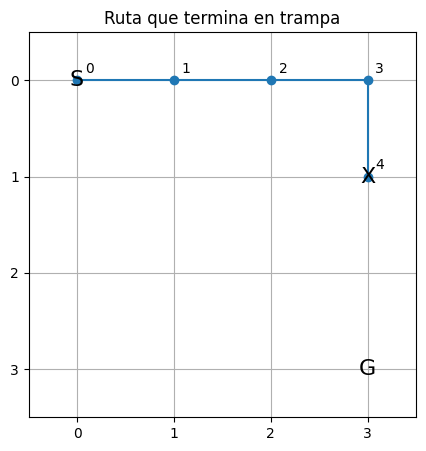

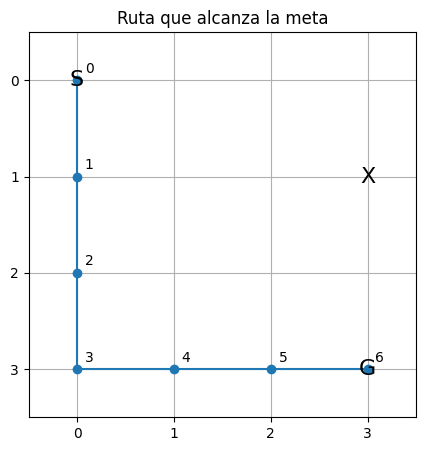

In [42]:
def plot_path(env, states, title="Camino recorrido"):
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.set_xlim(-0.5, env.cols - 0.5)
    ax.set_ylim(env.rows - 0.5, -0.5)
    ax.set_xticks(range(env.cols))
    ax.set_yticks(range(env.rows))
    ax.grid(True)

    ax.text(env.start[1], env.start[0], "S", ha="center", va="center", fontsize=16)
    ax.text(env.goal[1], env.goal[0], "G", ha="center", va="center", fontsize=16)
    ax.text(env.trap[1], env.trap[0], "X", ha="center", va="center", fontsize=16)

    ys = [s[0] for s in states]
    xs = [s[1] for s in states]
    ax.plot(xs, ys, marker="o")

    for i, (y, x) in enumerate(states):
        ax.text(x + 0.08, y - 0.08, str(i), fontsize=10)

    ax.set_title(title)
    plt.show()

env = SimpleGridWorld()
plot_path(env, states_a, title="Ruta que termina en trampa")
plot_path(env, states_b, title="Ruta que alcanza la meta")

# 14. Aprender una política en vez de escribirla a mano

Hasta ahora hemos usado:

- política aleatoria,
- políticas artesanales.

Pero RL trata de **aprender** una política.

En la sesión 2 veremos con detalle Q-learning y Bellman.
Aun así, para cerrar esta primera sesión, es muy útil ver un adelanto intuitivo de un agente que mejora por experiencia.

## Primer vistazo a Q-learning

Hasta ahora hemos visto políticas fijas: unas aleatorias y otras escritas a mano.  
Pero la idea central de Reinforcement Learning no es escribir nosotros la estrategia, sino **hacer que el agente la aprenda a partir de la experiencia**.

En esta sección vamos a usar **Q-learning**, uno de los algoritmos más clásicos e importantes de RL.

La idea general es la siguiente:

- el agente empieza sin saber qué hacer,
- prueba acciones en el entorno,
- observa qué recompensa obtiene,
- y va construyendo una tabla `Q` con lo “prometedora” que parece cada acción en cada estado.

Esa tabla tiene esta interpretación:

- filas -> estados
- columnas -> acciones
- valor `Q(s, a)` -> estimación de lo buena que es la acción `a` cuando el agente está en el estado `s`

Al principio todos los valores de la tabla valen 0, porque el agente todavía no sabe nada.  
Conforme interactúa con el entorno, la tabla se va corrigiendo poco a poco.

---

## Idea intuitiva de la actualización

Cuando el agente está en un estado `s`, elige una acción `a`, llega a un nuevo estado `s'` y recibe una recompensa `r`.

Entonces Q-learning se pregunta:

> “¿Lo que yo pensaba de esta acción era demasiado optimista o demasiado pesimista?”

Para corregirse, usa esta actualización:

$$
Q(s,a) \leftarrow Q(s,a) + \alpha \left[r + \gamma \max_{a'} Q(s',a') - Q(s,a)\right]
$$

No hace falta memorizarla de inmediato.  
Lo importante es entender sus piezas:

- `Q(s,a)` = lo que creíamos antes sobre esa acción
- `r` = recompensa inmediata
- `max Q(s',a')` = mejor futuro que creemos posible desde el nuevo estado
- `gamma` = cuánto nos importa ese futuro
- `alpha` = cuánto corregimos nuestra estimación

---

## Qué esperamos que ocurra durante el entrenamiento

Al principio:

- el agente explorará mucho,
- cometerá errores,
- caerá en trampas,
- y sus retornos serán irregulares.

Con el tiempo:

- irá descubriendo rutas mejores,
- la tabla `Q` empezará a reflejar qué acciones son útiles,
- y la política greedy derivada de `Q` tenderá a mejorar.

Este proceso de mejora no siempre es perfectamente suave.  
Es normal ver ruido, altibajos y episodios malos incluso cuando el agente ya está aprendiendo.

In [45]:
def q_learning(
    env,
    episodes=300,
    alpha=0.1,
    gamma=0.95,
    epsilon=1.0,
    epsilon_decay=0.995,
    epsilon_min=0.05,
    max_steps=50,
    seed=0
):
    """
    Entrena un agente con Q-learning en un entorno discreto.

    Parámetros
    ----------
    env : entorno
        Nuestro GridWorld. Debe tener:
        - reset()
        - step(action)
        - state_to_id(state)
        - rows y cols
        - goal

    episodes : int
        Número de episodios de entrenamiento.
        Cada episodio equivale a "un intento completo" del agente.

    alpha : float
        Learning rate o tasa de aprendizaje.
        Controla cuánto corregimos el valor Q en cada actualización.

    gamma : float
        Discount factor.
        Indica cuánto importan las recompensas futuras.

    epsilon : float
        Probabilidad inicial de explorar.
        Si epsilon=1.0, al principio el agente actúa casi totalmente al azar.

    epsilon_decay : float
        Factor por el que multiplicamos epsilon después de cada episodio.
        Sirve para que el agente explore mucho al principio y menos después.

    epsilon_min : float
        Valor mínimo que permitimos para epsilon.
        Así evitamos que la exploración desaparezca por completo.

    max_steps : int
        Número máximo de pasos permitidos por episodio.
        Esto evita episodios infinitos si el agente se queda dando vueltas.

    seed : int
        Semilla para reproducibilidad.

    Devuelve
    --------
    Q : np.ndarray
        Tabla Q aprendida. Tiene forma (n_states, n_actions).

    returns : np.ndarray
        Retorno total obtenido en cada episodio.

    success_rates : np.ndarray
        Tasa de éxito acumulada a lo largo del entrenamiento.
    """

    # ------------------------------------------------------------
    # 1. Generador aleatorio
    # ------------------------------------------------------------
    # Usamos un generador aleatorio de NumPy con semilla fija
    # para que el experimento sea reproducible.
    rng = np.random.default_rng(seed)

    # ------------------------------------------------------------
    # 2. Tamaño del espacio de estados y acciones
    # ------------------------------------------------------------
    # En este GridWorld, cada celda es un estado posible.
    # Si el grid es 4x4, entonces hay 16 estados.
    n_states = env.rows * env.cols

    # Tenemos 4 acciones posibles:
    # 0 = arriba, 1 = derecha, 2 = abajo, 3 = izquierda
    n_actions = 4

    # ------------------------------------------------------------
    # 3. Inicialización de la tabla Q
    # ------------------------------------------------------------
    # Creamos una matriz de ceros con forma:
    # (número de estados, número de acciones)
    #
    # Q[s, a] almacenará nuestra estimación actual de
    # "qué tan buena es la acción a en el estado s"
    #
    # Empezamos con ceros porque el agente aún no sabe nada.
    Q = np.zeros((n_states, n_actions))

    # ------------------------------------------------------------
    # 4. Variables para monitorizar el entrenamiento
    # ------------------------------------------------------------
    # returns guardará el retorno total de cada episodio
    returns = []

    # success_rates guardará la tasa de éxito acumulada
    # después de cada episodio
    success_rates = []

    # contador total de episodios que terminan en la meta
    successes = 0

    # ============================================================
    # BUCLE PRINCIPAL DE ENTRENAMIENTO
    # ============================================================
    # Vamos a repetir muchos episodios.
    # En cada episodio el agente empieza desde cero y aprende
    # a partir de lo que le va ocurriendo.
    for ep in range(episodes):

        # --------------------------------------------------------
        # 5. Reiniciar el entorno al comienzo del episodio
        # --------------------------------------------------------
        # reset() devuelve el estado inicial del entorno
        state = env.reset()

        # Convertimos la tupla (fila, columna) a un índice entero
        # para poder usarlo como fila de la tabla Q
        state_id = env.state_to_id(state)

        # Aquí acumularemos la recompensa total del episodio actual
        episode_return = 0

        # --------------------------------------------------------
        # 6. Bucle interno: pasos dentro de un episodio
        # --------------------------------------------------------
        for _ in range(max_steps):

            # ----------------------------------------------------
            # 6.1 Selección de acción: epsilon-greedy
            # ----------------------------------------------------
            # Con probabilidad epsilon:
            #   exploramos -> elegimos una acción al azar
            #
            # Con probabilidad (1 - epsilon):
            #   explotamos -> elegimos la acción con mejor valor Q
            #
            # Esta mezcla entre explorar y explotar es clave en RL.
            if rng.random() < epsilon:
                action = rng.integers(n_actions)   # explorar
            else:
                action = np.argmax(Q[state_id])    # explotar

            # ----------------------------------------------------
            # 6.2 Aplicamos la acción al entorno
            # ----------------------------------------------------
            # El entorno responde con:
            # - el nuevo estado
            # - la recompensa
            # - si el episodio ha terminado
            result = env.step(action)

            # Convertimos el nuevo estado a índice entero
            next_state_id = env.state_to_id(result.next_state)

            # ----------------------------------------------------
            # 6.3 Construcción del objetivo TD (Temporal Difference target)
            # ----------------------------------------------------
            # Esta es la idea central de Q-learning:
            #
            # objetivo = recompensa inmediata
            #            + valor del mejor futuro posible
            #
            # Es decir:
            # "lo buena que fue esta acción" =
            #   lo que he ganado ahora
            #   +
            #   lo que creo que podré ganar después
            #
            # Si el episodio ha terminado, ya no hay futuro.
            # Por eso multiplicamos la parte futura por 0 en ese caso.
            td_target = result.reward + gamma * np.max(Q[next_state_id]) * (0 if result.terminated else 1)

            # ----------------------------------------------------
            # 6.4 Error TD
            # ----------------------------------------------------
            # Comparamos:
            # - lo que yo creía antes: Q[state_id, action]
            # - lo que ahora parece más razonable: td_target
            #
            # La diferencia entre ambos es el error TD.
            td_error = td_target - Q[state_id, action]

            # ----------------------------------------------------
            # 6.5 Actualización de la tabla Q
            # ----------------------------------------------------
            # Corregimos el valor antiguo moviéndolo un poco
            # hacia el valor objetivo.
            #
            # alpha controla cuánto corregimos.
            Q[state_id, action] += alpha * td_error

            # ----------------------------------------------------
            # 6.6 Actualización del retorno del episodio
            # ----------------------------------------------------
            # Sumamos la recompensa obtenida en este paso
            episode_return += result.reward

            # ----------------------------------------------------
            # 6.7 Avanzamos al siguiente estado
            # ----------------------------------------------------
            state_id = next_state_id

            # ----------------------------------------------------
            # 6.8 Si el episodio termina, salimos del bucle interno
            # ----------------------------------------------------
            if result.terminated:

                # Si terminó porque llegó a la meta, contamos éxito
                if result.next_state == env.goal:
                    successes += 1

                break

        # --------------------------------------------------------
        # 7. Guardar métricas del episodio
        # --------------------------------------------------------
        returns.append(episode_return)

        # Tasa de éxito acumulada hasta este episodio
        success_rates.append(successes / (ep + 1))

        # --------------------------------------------------------
        # 8. Reducir epsilon para explorar menos con el tiempo
        # --------------------------------------------------------
        # Al principio queremos mucha exploración.
        # Más adelante queremos aprovechar lo aprendido.
        #
        # Pero nunca dejamos que epsilon baje de epsilon_min.
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    # ------------------------------------------------------------
    # 9. Devolvemos resultados
    # ------------------------------------------------------------
    # - Q: tabla aprendida
    # - returns: retorno por episodio
    # - success_rates: evolución de la tasa de éxito
    return Q, np.array(returns), np.array(success_rates)

In [46]:
env = SimpleGridWorld()
Q, training_returns, training_success = q_learning(env, episodes=500, seed=42)

print("Forma de la tabla Q:", Q.shape)
print("\nPrimeras filas de Q:")
print(Q[:6])

Forma de la tabla Q: (16, 4)

Primeras filas de Q:
[[ 6.584  7.009  7.285  6.683]
 [ 4.275  2.991  7.755  4.652]
 [ 1.722  0.256  6.354  1.561]
 [ 0.037  0.042 -2.609  1.251]
 [ 6.62   7.774  7.601  6.981]
 [ 6.828  7.19   8.288  7.043]]


## Comparando comportamiento antes y después de aprender

Ahora vamos a hacer algo muy ilustrativo.

Hasta ahora hemos visto que el algoritmo Q-learning va construyendo una tabla `Q`
que estima qué acciones son mejores en cada estado.

Pero ¿cómo cambia realmente el comportamiento del agente?

Para verlo vamos a comparar dos situaciones:

1. **Antes de aprender**  
   La tabla `Q` está llena de ceros.  
   El agente no tiene ninguna información sobre el entorno.

2. **Después de aprender**  
   Usamos la tabla `Q` que hemos obtenido tras el entrenamiento.

En ambos casos construiremos una política **greedy respecto a Q**, es decir:

$$
\pi(s) = \arg\max_a Q(s,a)
$$

y veremos paso a paso qué decisiones toma el agente en el grid.

In [56]:
import time
from IPython.display import clear_output

def animate_policy_from_q(env, Q, max_steps=30, delay=0.8):
    """
    Ejecuta un episodio usando una política greedy derivada de una Q-table
    y muestra el proceso como una animación en el notebook.
    """

    state = env.reset()
    state_id = env.state_to_id(state)

    total_reward = 0

    clear_output(wait=True)
    print("Estado inicial")
    print(f"Estado: {state}")
    print(f"Retorno acumulado: {total_reward:.2f}\n")
    env.render_text()

    time.sleep(delay)

    for step in range(1, max_steps + 1):

        # política greedy respecto a Q
        action = np.argmax(Q[state_id])

        result = env.step(action)

        total_reward += result.reward

        state = result.next_state
        state_id = env.state_to_id(state)

        clear_output(wait=True)

        print(f"Paso {step}")
        print(f"Acción elegida: {ACTIONS[action]}")
        print(f"Estado actual: {state}")
        print(f"Recompensa: {result.reward}")
        print(f"Retorno acumulado: {total_reward:.2f}")
        print(f"Episodio terminado: {result.terminated}\n")

        env.render_text()

        time.sleep(delay)

        if result.terminated:

            print("\nFin del episodio")

            if state == env.goal:
                print("El agente ha llegado a la META")
            elif state == env.trap:
                print("El agente ha caído en la TRAMPA")

            break

In [57]:
# Creamos una Q-table llena de ceros
n_states = env.rows * env.cols
n_actions = 4

Q_empty = np.zeros((n_states, n_actions))

print("Comportamiento del agente con Q-table inicial (sin aprendizaje)\n")

env = SimpleGridWorld()

animate_policy_from_q(env, Q_empty, delay=0.8)

Paso 30
Acción elegida: arriba
Estado actual: (0, 0)
Recompensa: -0.1
Retorno acumulado: -3.00
Episodio terminado: False

S . . .
. . . X
. . . .
. . . G


In [58]:
print("Comportamiento del agente con Q-table aprendida\n")

env = SimpleGridWorld()

animate_policy_from_q(env, Q, delay=0.8)

Paso 6
Acción elegida: derecha
Estado actual: (3, 3)
Recompensa: 10.0
Retorno acumulado: 9.50
Episodio terminado: True

S . . .
. . . X
. . . .
. . . G

Fin del episodio
El agente ha llegado a la META


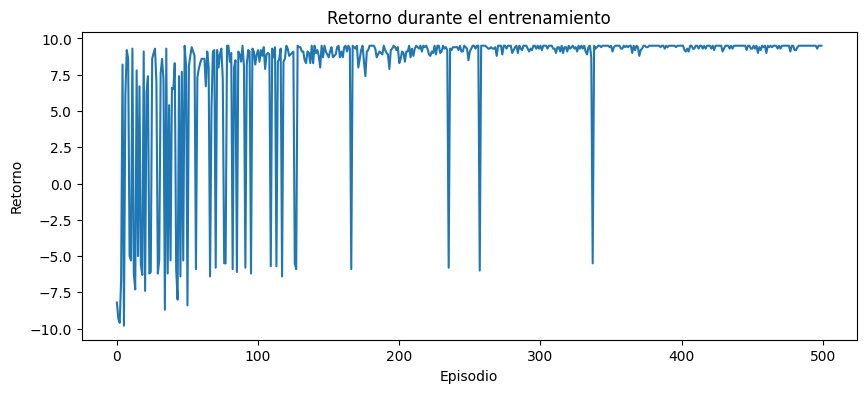

In [48]:
plt.figure(figsize=(10, 4))
plt.plot(training_returns)
plt.xlabel("Episodio")
plt.ylabel("Retorno")
plt.title("Retorno durante el entrenamiento")
plt.show()

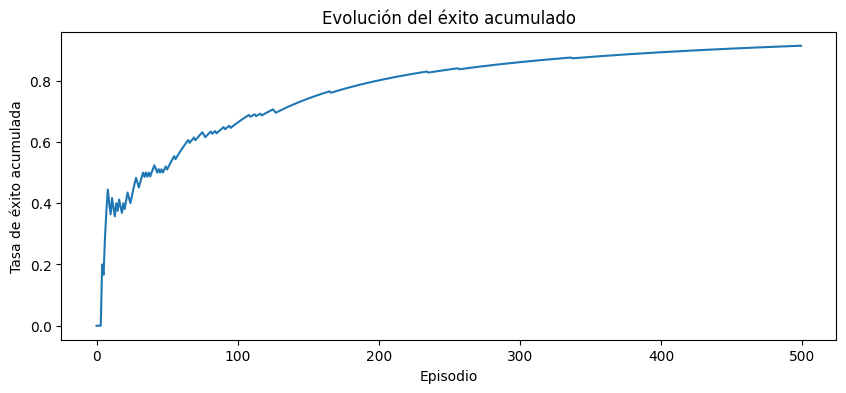

In [49]:
plt.figure(figsize=(10, 4))
plt.plot(training_success)
plt.xlabel("Episodio")
plt.ylabel("Tasa de éxito acumulada")
plt.title("Evolución del éxito acumulado")
plt.show()

Aunque la curva pueda tener ruido, suele verse una tendencia de mejora.

Esto es justo lo interesante de RL:

- no damos al agente la solución explícita,
- dejamos que interactúe,
- y a partir de recompensas aprende progresivamente a comportarse mejor.

In [50]:
def learned_policy_from_Q(Q, env):
    def policy(state):
        state_id = env.state_to_id(state)
        return np.argmax(Q[state_id])
    return policy

env = SimpleGridWorld()
learned_policy = learned_policy_from_Q(Q, env)

episode_learned = run_episode(env, learned_policy, verbose=True)

print("\nResumen del episodio aprendido")
print("Acciones:", [ACTIONS[a] for a in episode_learned["actions"]])
print("Recompensas:", episode_learned["rewards"])
print("Retorno:", episode_learned["return"])
print("Estado final:", episode_learned["states"][-1])

Paso 01 | estado=(0, 0) | acción=    abajo | nuevo_estado=(1, 0) | recompensa=-0.1 | terminado=False
Paso 02 | estado=(1, 0) | acción=  derecha | nuevo_estado=(1, 1) | recompensa=-0.1 | terminado=False
Paso 03 | estado=(1, 1) | acción=    abajo | nuevo_estado=(2, 1) | recompensa=-0.1 | terminado=False
Paso 04 | estado=(2, 1) | acción=    abajo | nuevo_estado=(3, 1) | recompensa=-0.1 | terminado=False
Paso 05 | estado=(3, 1) | acción=  derecha | nuevo_estado=(3, 2) | recompensa=-0.1 | terminado=False
Paso 06 | estado=(3, 2) | acción=  derecha | nuevo_estado=(3, 3) | recompensa=10.0 | terminado=True

Resumen del episodio aprendido
Acciones: ['abajo', 'derecha', 'abajo', 'abajo', 'derecha', 'derecha']
Recompensas: [-0.1, -0.1, -0.1, -0.1, -0.1, 10.0]
Retorno: 9.5
Estado final: (3, 3)


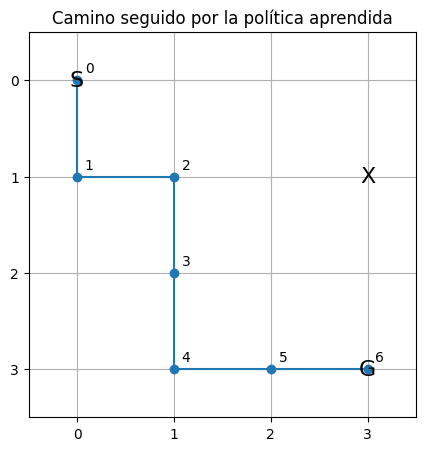

In [51]:
plot_path(SimpleGridWorld(), episode_learned["states"], title="Camino seguido por la política aprendida")

# 15. Inspección más fina: ¿qué acción prefiere el agente en cada estado?

Otra manera muy pedagógica de mirar la política aprendida es imprimir, para cada casilla, la acción preferida.

Usaremos flechas:

- ↑ arriba
- → derecha
- ↓ abajo
- ← izquierda

In [53]:
arrow_map = {0: "↑", 1: "→", 2: "↓", 3: "←"}

def print_policy_grid(Q, env):
    for r in range(env.rows):
        row_symbols = []
        for c in range(env.cols):
            state = (r, c)
            if state == env.goal:
                row_symbols.append(" G ")
            elif state == env.trap:
                row_symbols.append(" X ")
            else:
                action = np.argmax(Q[env.state_to_id(state)])
                row_symbols.append(f" {arrow_map[action]} ")
        print("".join(row_symbols))

env = SimpleGridWorld()
print_policy_grid(Q, env)

 ↓  ↓  ↓  ← 
 →  ↓  ↓  X 
 →  ↓  →  ↓ 
 →  →  →  G 


# 16. El reward define el comportamiento: pequeño experimento

Vamos a cambiar el coste por paso.

- Si el coste por paso es más negativo, el agente debería tener más prisa por terminar.
- Si el coste es casi cero, quizá el agente tolere rutas más largas.

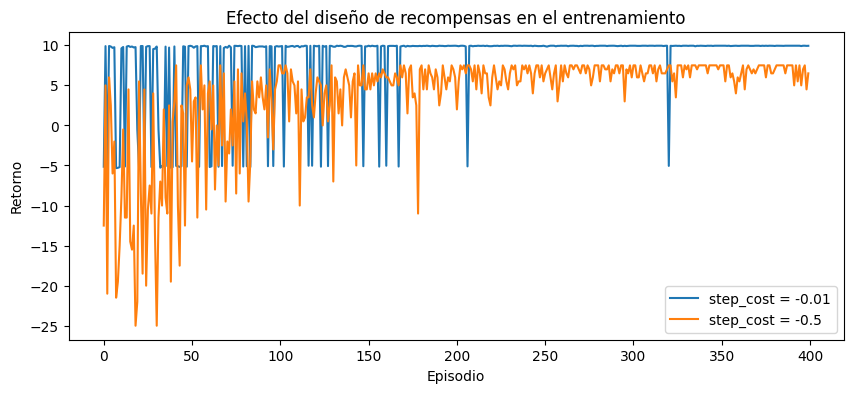

In [54]:
env_low_cost = SimpleGridWorld(step_cost=-0.01)
Q_low, returns_low, success_low = q_learning(env_low_cost, episodes=400, seed=1)

env_high_cost = SimpleGridWorld(step_cost=-0.5)
Q_high, returns_high, success_high = q_learning(env_high_cost, episodes=400, seed=1)

plt.figure(figsize=(10, 4))
plt.plot(returns_low, label="step_cost = -0.01")
plt.plot(returns_high, label="step_cost = -0.5")
plt.xlabel("Episodio")
plt.ylabel("Retorno")
plt.title("Efecto del diseño de recompensas en el entrenamiento")
plt.legend()
plt.show()

# 17. Resumen conceptual de la sesión

## Lo esencial que hay que recordar

### RL no es predecir etiquetas
No se trata de decir "esta entrada pertenece a esta clase".
Se trata de **aprender a actuar**.

### La interacción con el entorno es central
El agente aprende a partir de:

- estados,
- acciones,
- recompensas,
- consecuencias.

### La recompensa guía el aprendizaje
Lo que el agente acaba haciendo depende mucho de cómo premiamos o castigamos.

### El objetivo es secuencial
No importa solo el siguiente paso.
Importa el efecto acumulado de una cadena de decisiones.

### La exploración es necesaria
Sin explorar, el agente podría no descubrir estrategias mejores.

### La política es el comportamiento del agente
Una política indica qué acción tomar en cada estado.

# 18. Mini ejercicios (ya sabéis, la utopía de un profe ingenuo...)

## Ejercicio 1
Modifica la posición de la trampa y observa cómo cambia la política aprendida.

## Ejercicio 2
Añade una segunda trampa al entorno y vuelve a entrenar.

## Ejercicio 3
Prueba distintos valores de:
- `alpha`
- `gamma`
- `epsilon_decay`

y comenta qué cambios observas.

## Ejercicio 4
Diseña una política artesanal nueva y compárala con:
- la aleatoria,
- la artesanal segura,
- la política aprendida.

## Ejercicio 5
Haz que chocar con una pared tenga una penalización extra y estudia si el agente aprende a evitar esos intentos.